# COE 311K Final Project - Part 1 of 3 by Vishnu Prasad (vp9439)

## Section 1: Introduction & Model Selection

In order to practice applying numerical methods to solve second-order ordinary differential equations, we will consider the application of a car suspension system, which is an example of a spring-mass system. 

For a spring-mass system, this is the governing second-order ODE:

## $m$$\frac{d^2y}{dt^2}$ + $c$$\frac{dy}{dt}$ + $k$$y$ = 0

Where:

$m$ = mass (kg)

$c$ = damping coefficient (N·s/m)

$k$ = spring constant (N/m)

$y(t)$ = displacement from equilibrium (m)

This second order ODE can be converted to the following system of first-order ODEs:

## 1. $\frac{dy}{dt}$ = $v$
## 2. $\frac{dv}{dt}$ = $\frac{-cv-ky}{m}$

## Section 2: Parameter Research & Justification

Parameter | Value | Source
---:|:---:| ---
**Mass (m)** | Dave | _Steve_
**Damping Coefficient (c)** | Gregg | _Karen_
**Spring Constant (k)** | Diane | _Jorge_

The suspension system ODE will be defined by the following inital conditions:

$y(0)$ = 0.05 (m)

$y'(0)$ = 0 (m/s)

Physically, these initial conditions can be interpreted as the car passing over the peak of a 5 cm speed bump with the suspension fully compressed, so the velocity is zero at the top. After the initial displacement, we model the resulting dampening oscillations of the suspension unit using numerical methods.

## Section 3: Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 300 # mass (kg)
c = 1500 # damping coefficient (N·s/m)
k = 25000 # spring constant (N/m)
h_values = np.array([0.05, 0.01, 0.005]) # Different step sizes to test stability
t_start = 0 # Start time (s)
t_end = 5 # End time (s)
y_0 = 0.05 # Initial position (m)
v_0 = 0 # Initial velocity (m/s)

# Function representing dv/dt
def f(y,v):
    return (-c*v - k*y)/m

# Euler's method function
def euler_method(f, h, t_start, t_end, y_0, v_0):
    # Create arrays to store t, y, and v values
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    
    # Euler's Method loop
    for i in range(1, len(t_values)):
        # Current values
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * f(y_n, v_n)
    
    return t_values, y_values, v_values

# RK4 Method
def runge_kutta_4(f, h, t_start, t_end, y_0, v_0):
    # Create arrays to store t, y, and v values
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values)) 
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        # Current values
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        k1_y = h * v_n
        k1_v = h * f(y_n, v_n)

        k2_y = h * (v_n + k1_v/2)
        k2_v = h * f(y_n + k1_y/2, v_n + k1_v/2)

        k3_y = h * (v_n + k2_v/2)
        k3_v = h * f(y_n + k2_y/2, v_n + k2_v/2)

        k4_y = h * (v_n + k3_v)
        k4_v = h * f(y_n + k3_y, v_n + k3_v)
        
        # Update y and v based on the RK4 formula
        y_values[i] = y_n + (k1_y + 2 * k2_y + 2 * k3_y + k4_y) / 6
        v_values[i] = v_n + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6
        
    return t_values, y_values, v_values

My implementation approach breaks up the governing second-order differential equation into a system of two first-order differential equations for position and velocity. For each step, Euler's Method updates position and velocity using the current slopes from the first-order system. On the other hand, RK4 evaluates the slope at 4 points between each time step and takes the weighted average, which gives a much better approximation.

## Section 4: Solutions & Comparison

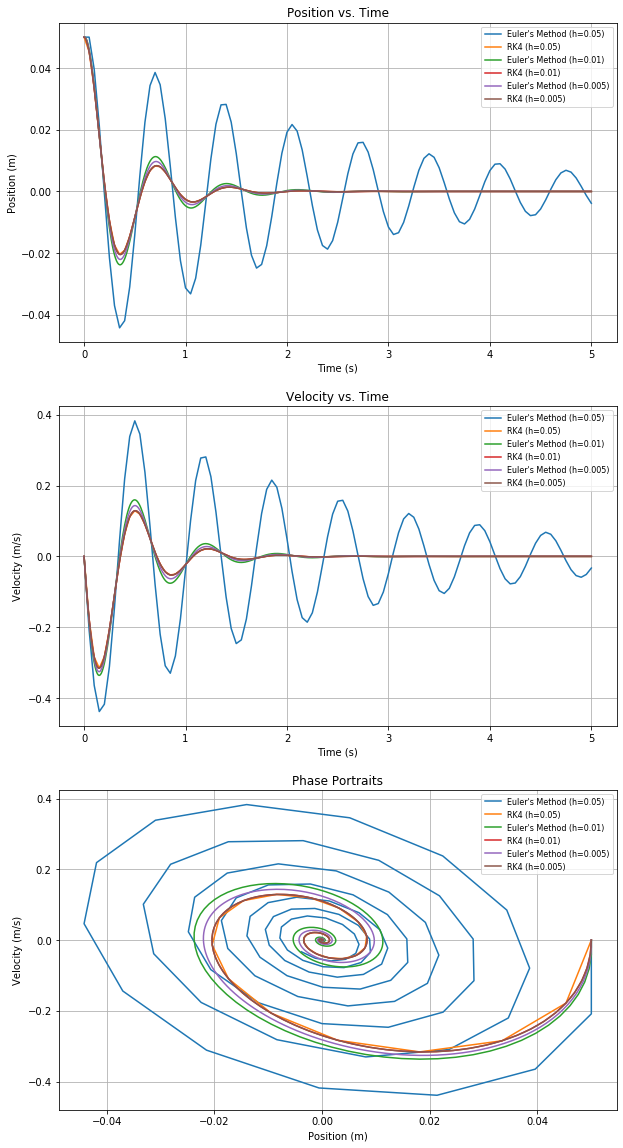

In [2]:
# Plot results for different step sizes
fig, axs = plt.subplots(3, 1, figsize=(10, 20))
for h in h_values:
    # Get t, y, and v arrays from Euler's Method and RK4
    t_euler, y_euler, v_euler = euler_method(f, h, t_start, t_end, y_0, v_0)
    t_RK4, y_RK4, v_RK4 = runge_kutta_4(f, h, t_start, t_end, y_0, v_0)
    
    # Position vs. Time plot
    axs[0].plot(t_euler, y_euler, label=f'Euler\'s Method (h={h})')
    axs[0].plot(t_RK4, y_RK4, label=f'RK4 (h={h})')
    
    # Velocity vs. Time plot
    axs[1].plot(t_euler, v_euler, label=f'Euler\'s Method (h={h})')
    axs[1].plot(t_RK4, v_RK4, label=f'RK4 (h={h})')\
    
    # Phase Portraits
    axs[2].plot(y_euler, v_euler, label=f'Euler\'s Method (h={h})')
    axs[2].plot(y_RK4, v_RK4, label=f'RK4 (h={h})')
    
# Formatting plots
axs[0].set_title('Position vs. Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Position (m)')

axs[1].set_title('Velocity vs. Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Velocity (m/s)')

axs[2].set_title('Phase Portraits')
axs[2].set_xlabel('Position (m)')
axs[2].set_ylabel('Velocity (m/s)')

for ax in axs:
    ax.legend(fontsize=8)
    ax.grid()

plt.show()

From the comparison plots (position vs. time / velocity vs. time), we can observe that Euler's Method becomes unstable much more quickly than RK4 as step size is increased. This instability is reflected by larger amplitude distortions in Euler's Method and phase shifts compared to how RK4 maintains accurate damped oscillations even at higher step sizes.

## Section 5: Stability Analysis

As demonstrated previously, the numerical solutions for both Euler's Method and RK4 become less accurate as step size is increased, even though Euler's Method diverges much faster than RK4. 

To determine the maximum stable step size for Euler's Method, ∣1+hλ∣ ≤ 1 must be satisfied. Since the system we are solving is underdamped, we can apply λ = α±iβ into the previous equation and simplify to reach the stability condition h < $\frac{c}{k}$. Using the researched parameters for c and k, the stability condition for Euler's Method is h < 0.06. This is supported by the comparison plots since Euler's Method was close to diverging at around h = 0.05, which is almost at the theoretical limit.

To determine the maximum stable step size for RK4, start with the the stability function: R(z)=1+z+$\frac{z^2}{2}$+$\frac{z^3}{6}$+$\frac{z^4}{24}$, where z = hλ and ∣R(z)∣ ≤ 1. For practical purposes we can simplify the stability region to be approximately h ≤ $\frac{1.6}{\sqrt{k/m}}$. By plugging in the researched parameters, we can arrive at a stability condition of h < 0.18, which is expectedly much higher than the stability condition for Euler's Method.

When the step size becomes large enough to violate the stability condition, the numerical solution becomes unstable. This instability can create distorted and amplified oscillations, where trajectories spiral outward rather than inward in the phase portrait, indicative of divergence.

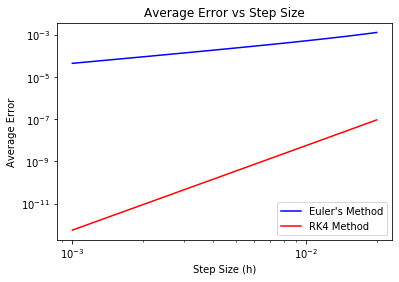

Euler's Method Convergence Rate: 1.1243369657179092
RK4 Convergence Rate: 4.012960371743455


In [8]:
# Exact solution function
def y_exact(m, c, k, y_0, v_0, t):
    alpha = -c / (2*m)
    beta = np.sqrt(4*m*k - c**2) / (2*m)
    C_1 = y_0
    C_2 = (v_0 - alpha * y_0) / beta
    
    return np.exp(alpha * t)*(C_1*np.cos(beta*t) + C_2*np.sin(beta*t))

# Set up error arrays
error_h = np.linspace(0.001, 0.02, 50)
error_euler = np.zeros(len(h_values))
error_RK4 = np.zeros(len(h_values))

for index, h in enumerate(h_values):
    # Get t, y, and v arrays from Euler's Method and RK4
    t_euler, y_euler, v_euler = euler_method(f, h, t_start, t_end, y_0, v_0)
    t_RK4, y_RK4, v_RK4 = runge_kutta_4(f, h, t_start, t_end, y_0, v_0)
    
    # Average Error
    y_exact_euler = y_exact(m, c, k, y_0, v_0, t_euler)
    y_exact_RK4 = y_exact(m, c, k, y_0, v_0, t_RK4)
    error_euler[index] = np.mean(np.abs((y_exact_euler - y_euler)))
    error_RK4[index] = np.mean(np.abs((y_exact_RK4 - y_RK4)))

# Logarithms plots
plt.loglog(h_values, error_euler, color = 'blue', label = 'Euler\'s Method')
plt.loglog(h_values, error_RK4, color = 'red', label = 'RK4 Method')
plt.xlabel('Step Size (h)')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.legend()
plt.show()

# Calculate slopes
euler_slope = (np.log(error_euler[-1]) - np.log(error_euler[0])) / (np.log(error_h[-1]) - np.log(error_h[0]))
RK4_slope = (np.log(error_RK4[-1]) - np.log(error_RK4[0])) / (np.log(error_h[-1]) - np.log(error_h[0]))

print(f'Euler\'s Method Convergence Rate: {euler_slope}')
print(f'RK4 Convergence Rate: {RK4_slope}')

Numerical instabilities almost always lead to non-physical results, because they deviate from the governing differential equation. This system is a damped system, so total mechanical energy should decrease over time leading to decaying oscillations. However, with numerical instability, artificial energy gets injected into the system, which causes oscillations to grow instead of decay. In the context of the car suspension system, numerical instabilities will cause the sprung mass of the car to somehow gain motion without any external force which contradicts the physics of a spring-mass damping system.

## Section 6: Conclusions

RK4 outperformed Euler's Method for this scenario in terms of stability and accuracy. Euler's Method quickly becomes inaccurate beyond small step sizes while RK4 remains stable for larger step size, which means that RK4 can model energy decay much more realistically than Euler's Method. RK4 has a time complexity of O(h^4) while Euler's Method has a time complexity of O(h), indicating that for a constant step size, the tradeoff for RK4's accuracy is its computational cost. However, since RK4 has a much broader stability condition, it typically requires less steps than Euler's Method, meaning that RK4 is usually cheaper overall to achieve a certain accuracy.

A practical recommendation would be to use Euler's Method if you are modeling short-time behavior where step size is small. Otherwise, to adhere to real dynamics in a long-term scenario, RK4 is more accurate and stable. One lesson to take away from this project is that higher-order methods are practically necessary to accurately model dynamical systems.